In [ ]:
from google.colab import files

uploaded =files.upload()
print(uploaded)

Saving movie_dataset.csv to movie_dataset.csv
{'movie_dataset.csv': b'Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3\r\n ,,,Drama,,,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia\r\n#Gadhvi (He thought he was Gandhi),-2019,109 min,Drama,7,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid\r\n#Homecoming,-2021,90 min,"Drama, Musical",,,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana\r\n#Yaaram,-2019,110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor\r\n...And Once Again,-2010,105 min,Drama,,,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali\r\n...Aur Pyaar Ho Gaya,-1997,147 min,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor\r\n...Yahaan,-2005,142 min,"Drama, Romance, War",7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma\r\n.in for Motion,-2008,59 min,Documentary,,,Anirban Datta,,,\r\n?: A Question Mark,-2012,82 min,"Horror, Mystery, Thrille

In [9]:
import pandas as pd


data = pd.read_csv("movie_dataset.csv", encoding="latin1")
print(data)
print(data.columns.tolist())
print(data.isnull().sum())

                                     Name    Year Duration            Genre  \
0                                             NaN      NaN            Drama   
1      #Gadhvi (He thought he was Gandhi) -2019.0  109 min            Drama   
2                             #Homecoming -2021.0   90 min   Drama, Musical   
3                                 #Yaaram -2019.0  110 min  Comedy, Romance   
4                       ...And Once Again -2010.0  105 min            Drama   
...                                   ...     ...      ...              ...   
15504                 Zulm Ko Jala Doonga -1988.0      NaN           Action   
15505                               Zulmi -1999.0  129 min    Action, Drama   
15506                           Zulmi Raj -2005.0      NaN           Action   
15507                       Zulmi Shikari -1988.0      NaN           Action   
15508                        Zulm-O-Sitam -1998.0  130 min    Action, Drama   

       Rating Votes            Director           A

In [14]:
print("droping missing values in rating")
data = data.dropna(subset=['Rating'])
print(data)
print("checking missing values")
print(data.isnull().sum())
print(data.dtypes)

droping missing values in rating
                                     Name    Year Duration  \
1      #Gadhvi (He thought he was Gandhi) -2019.0  109 min   
3                                 #Yaaram -2019.0  110 min   
5                    ...Aur Pyaar Ho Gaya -1997.0  147 min   
6                               ...Yahaan -2005.0  142 min   
8                      ?: A Question Mark -2012.0   82 min   
...                                   ...     ...      ...   
15501                     Zulm Ki Hukumat -1992.0      NaN   
15503                     Zulm Ki Zanjeer -1989.0  125 min   
15504                 Zulm Ko Jala Doonga -1988.0      NaN   
15505                               Zulmi -1999.0  129 min   
15508                        Zulm-O-Sitam -1998.0  130 min   

                           Genre  Rating  Votes           Director  \
1                          Drama     7.0      8      Gaurav Bakshi   
3                Comedy, Romance     4.4     35         Ovais Khan   
5         Co

In [22]:
print("datatype conversion for duration column")
print(data['Duration'].dtype)
print(data['Duration'].head(10))
data['Duration'] = data['Duration'].fillna(
    data['Duration'].median()
)

datatype conversion for duration column
float64
1     109.0
3     110.0
5     147.0
6     142.0
8      82.0
9     116.0
10     96.0
11    120.0
12    161.0
13    166.0
Name: Duration, dtype: float64


In [34]:
data['Votes'] = data['Votes'].astype(str)

data['Votes'] = data['Votes'].str.replace(',', '', regex=False)

data['Votes'] = pd.to_numeric(data['Votes'], errors='coerce')


print(data['Votes'].dtype)
print(data['Votes'].head())


data['Votes'] = data['Votes'].fillna(data['Votes'].median)
print(data.columns.tolist())
print(data.isnull().sum())

int64
1       8
3      35
5     827
6    1086
8     326
Name: Votes, dtype: int64
['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']
Name          0
Year          0
Duration      0
Genre       102
Rating        0
Votes         0
Director      5
Actor 1     125
Actor 2     200
Actor 3     292
dtype: int64


In [37]:
print("filling values in categerical columns")
data['Genre'] = data['Genre'].fillna(
    data['Genre'].mode()[0]
)

data['Director'] = data['Director'].fillna(
    data['Director'].mode()[0]
)

data['Actor 1'] = data['Actor 1'].fillna(
    data['Actor 1'].mode()[0]
)

data['Actor 2'] = data['Actor 2'].fillna(
    data['Actor 2'].mode()[0]
)

data['Actor 3'] = data['Actor 3'].fillna(
    data['Actor 3'].mode()[0]
)


print(data.columns.tolist())
print(data.isnull().sum())

filling values in categerical columns
['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']
Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64


vizualizing rating distributions


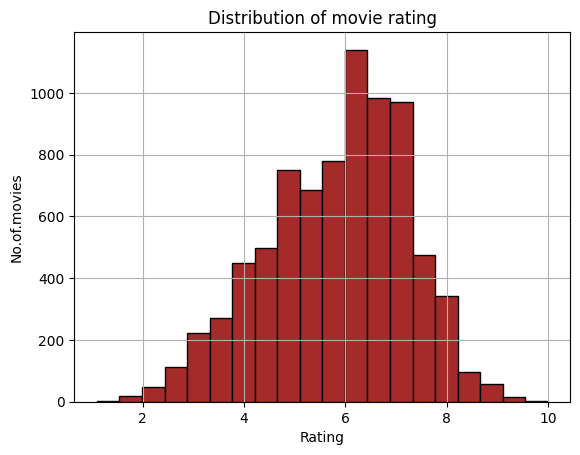

In [46]:
print("vizualizing rating distributions")
import matplotlib.pyplot as plt

data['Rating'].hist(bins=20,color ='brown',edgecolor = 'black')
plt.title("Distribution of movie rating")
plt.xlabel("Rating")
plt.ylabel("No.of.movies")
plt.show()




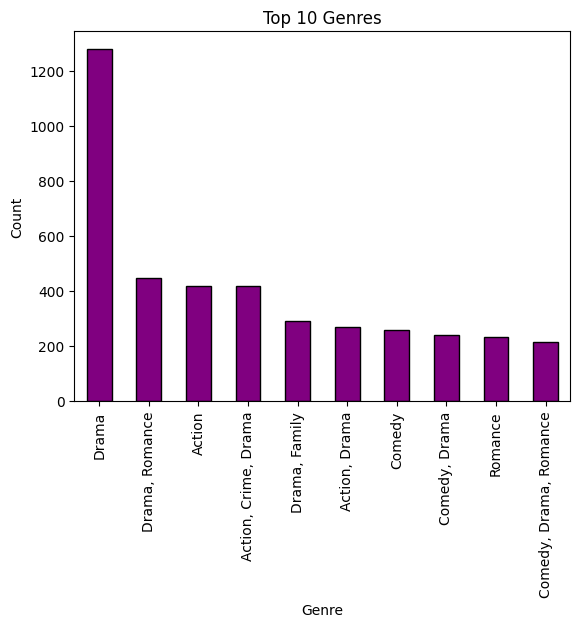

In [51]:
data['Genre'].value_counts().head(10).plot(
    kind='bar',
    color='purple',
    edgecolor='black'
)

plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

In [57]:
print("taining our data")

X = data[['Year',
          'Duration',
          'Genre',
          'Votes',
          'Director',
          'Actor 1',
          'Actor 2',
          'Actor 3']]

y = data['Rating']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


categorical_features = [
    'Genre',
    'Director',
    'Actor 1',
    'Actor 2',
    'Actor 3'
]

numeric_features = [
    'Year',
    'Duration',
    'Votes'
]

taining our data


In [60]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'),
         categorical_features)
    ],
    remainder='passthrough'
)

In [62]:
from sklearn.ensemble import RandomForestRegressor

from sklearn.pipeline import Pipeline

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)


from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)

Mean Absolute Error: 0.8030107323232322
R² Score: 0.37148983420575354


In [66]:
new_movie = pd.DataFrame({
    'Year': [2024],
    'Duration': [150],
    'Genre': ['Action'],
    'Votes': [5000],
    'Actor 1':['samantha'],
    'Actor 2':['sreemukhi'],
    'Actor 3':['mahesh'],
    'Director':['samantha']
})

predicted_rating = model.predict(new_movie)

print("Predicted Rating:", predicted_rating[0])

Predicted Rating: 8.216999999999992
